In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Loading Dataset

In [2]:
df = pd.read_csv("./traces.csv")
df.head()

,event_id,event_type,timestamp,run_id,sequence_number,agent_role,tool_name,tool_input,tool_output,prompt,...,memory_mb,goroutines,model_name,cost_usd,error_type,error_message,retry_count,queue_wait_ms,tokens_per_second,cache_hit
0,run-0000-evt-0001,run_started,2026-03-31T13:55:45.619011+08:00,run-0000,1,NaN,NaN,NaN,NaN,NaN,...,9.58,9,NaN,0.0,NaN,NaN,0,0,0.0,False
1,run-0000-evt-0002,agent_invoked,2026-03-31T13:55:45.619565+08:00,run-0000,2,supervisor,NaN,NaN,NaN,NaN,...,9.58,9,NaN,0.0,NaN,NaN,0,0,0.0,False
2,run-0001-evt-0001,run_started,2026-03-31T13:55:45.61906+08:00,run-0001,1,NaN,NaN,NaN,NaN,NaN,...,9.59,8,NaN,0.0,NaN,NaN,0,0,0.0,False
3,run-0001-evt-0002,agent_invoked,2026-03-31T13:55:45.61987+08:00,run-0001,2,supervisor,NaN,NaN,NaN,NaN,...,9.59,8,NaN,0.0,NaN,NaN,0,0,0.0,False
4,run-0002-evt-0001,run_started,2026-03-31T13:55:45.619039+08:00,run-0002,1,NaN,NaN,NaN,NaN,NaN,...,9.60,8,NaN,0.0,NaN,NaN,0,0,0.0,False


### Descriptive Statistics

In [3]:
print("1. =====DATAFRAME DESCRIBE=====")
print(df.describe())
print("\n\n\n2. =====EVENT TYPES=====")
print(df['event_type'].value_counts())
print("\n\n\n3. =====BULK OF LATENCY DESCRIBE=====")
print(df[(df["latency_ms"] > 500) & (df["latency_ms"] < 8000)]["latency_ms"].dropna().describe())

1. =====DATAFRAME DESCRIBE=====
       sequence_number  input_tokens  output_tokens    latency_ms  \
count       2033.00000   2033.000000    2033.000000   2033.000000   
mean          21.12543     40.651254     139.867191   1490.986719   
std           12.05044     87.163192     213.970326   3798.784634   
min            1.00000      0.000000       0.000000      0.000000   
25%           11.00000      0.000000       0.000000      0.000000   
50%           21.00000      0.000000       0.000000      0.000000   
75%           32.00000     55.000000     366.000000   3135.000000   
max           47.00000    710.000000     512.000000  41706.000000   

       execution_ns  cpu_percent    memory_mb   goroutines     cost_usd  \
count  2.033000e+03  2033.000000  2033.000000  2033.000000  2033.000000   
mean   1.213066e+09    14.832868     7.687068    11.859321     0.000185   
std    4.541597e+09     1.042422     1.999945     0.834117     0.000282   
min    3.670900e+04    10.030000     4.120000 

### Descriptive Statistics Analysis

1. Using describe on the whole dataframe presents data that is "zero-heavy"; therefore, need more conclusive details on what ranges we actually want to sample.  Finding the core feature we need to focus upon is the largest issue at hand, so we can look towards other methods, graphs, and charts for leading us to the answers.
2. When observing our event types, we can see the majority of our events lie within: llm_request_sent, llm_response_received, agent_invoked, agent_completed, message_sent, tool_called, tool_returned, routing_decided.  The fours categories outstanding are: run_started, run_completed, retry_started, error_occurred, which may be important in an operations sense; however, here they are considered noise, so those are our first candidates to be dropped.
3. While doing an analysis of the data the sequence of (500, 8000) stuck out as the best range to view the majority of data.  Subsequently, we wouldn't want to drop this data initially since some events may take place outside of the range, which may be important to latency, execution time, and overall agentic ai performance.  With a max of 6783ms and a min of 902ms, with a standard deviation of 944ms but a mean of 3679ms, the majority of our data with be right-skewed when viewing the "primetime" window.  Therefore, to get somewhat of a better picture 3000-5000ms might be a much better sequence to observe, so we will conduct further investigation to find where our data lies within the context of event types.

### Visualizations

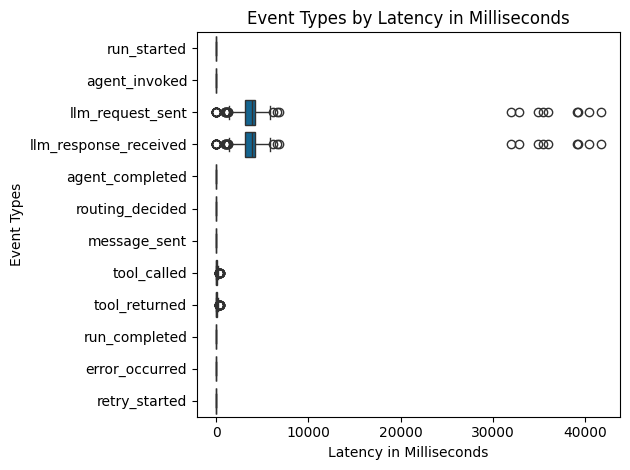

In [4]:
plt.style.use('tableau-colorblind10')
ax = sns.boxplot(data=df, x='latency_ms', y='event_type')
ax.set_title("Event Types by Latency in Milliseconds")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Event Types")
plt.tight_layout()
plt.show()

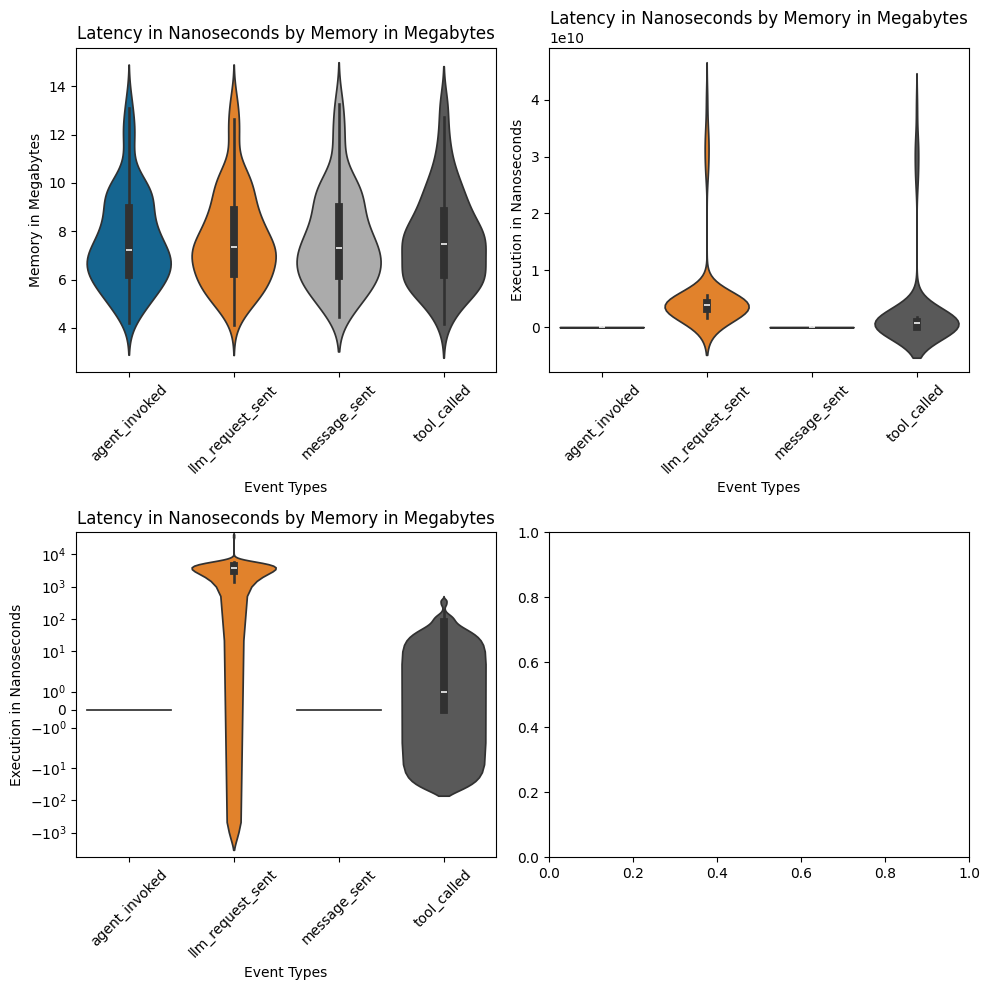

In [5]:
# blacklist events as noise
events_excluded = ["run_started", "agent_completed", "run_completed", "routing_decided", "error_occurred", "retry_started", "tool_returned", "llm_response_received"]

# Latency, Execution, and Memory DataFrame
lem_df = df[
    (~df['event_type'].isin(events_excluded)) & 
    ((df['latency_ms'] > 0) |
    (df['execution_ns'] > 0) |
    (df['memory_mb'] > 0))
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax = sns.violinplot(
    data=lem_df,
    y="memory_mb",
    x="event_type",
    hue="event_type",
    ax=axes[0][0]
)
ax.set_title("Latency in Nanoseconds by Memory in Megabytes")
ax.set_ylabel("Memory in Megabytes")
ax.set_xlabel("Event Types")
ax.tick_params(axis='x', labelrotation=45)

bx = sns.violinplot(
    data=lem_df,
    y="execution_ns",
    x="event_type",
    hue="event_type",
    ax=axes[0][1]
)
bx.set_title("Latency in Nanoseconds by Memory in Megabytes")
bx.set_ylabel("Execution in Nanoseconds")
bx.set_xlabel("Event Types")
bx.tick_params(axis='x', labelrotation=45)

cx = sns.violinplot(
    data=lem_df,
    y="latency_ms",
    x="event_type",
    hue="event_type",
    ax=axes[1][0]
)
cx.set_title("Latency in Nanoseconds by Memory in Megabytes")
cx.set_ylabel("Execution in Nanoseconds")
cx.set_xlabel("Event Types")
cx.tick_params(axis='x', labelrotation=45)
cx.set_yscale('symlog')

#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Event Types")

plt.tight_layout()
plt.show()

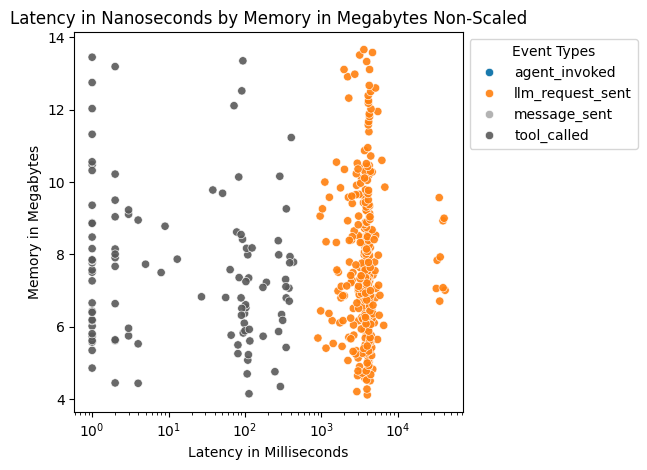

In [6]:
ax = sns.scatterplot(
    data=lem_df,
    x="latency_ms",
    y="memory_mb",
    hue="event_type",
    alpha=0.9
)
ax.set_title("Latency in Nanoseconds by Memory in Megabytes Non-Scaled")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Memory in Megabytes")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Event Types")
plt.xscale("log")
plt.tight_layout()
plt.show()

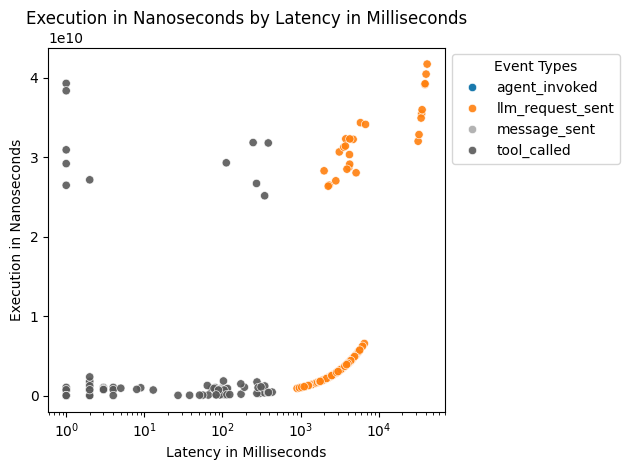

In [7]:
# blacklist events as noise
ax = sns.scatterplot(
    data=lem_df,
    x="latency_ms",
    y="execution_ns",
    hue="event_type",
    alpha=0.9
)
ax.set_title("Execution in Nanoseconds by Latency in Milliseconds")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Execution in Nanoseconds")

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Event Types")

# apply log since values are in separate SI units (ns vs ms)
plt.xscale("log")

plt.tight_layout()
plt.show()

# After seeing this visualization my hypothesis will be focused upon the curve around 10^3

[Text(0.5, 0, '(0.999, 1.873]'),
 Text(2.5, 0, '(2.0, 3.0]'),
 Text(4.5, 0, '(4.315, 6.553]'),
 Text(6.5, 0, '(8.72, 12.69]'),
 Text(8.5, 0, '(27.0, 38.0]'),
 Text(10.5, 0, '(51.0, 56.0]'),
 Text(12.5, 0, '(64.0, 66.825]'),
 Text(14.5, 0, '(74.04, 79.628]'),
 Text(16.5, 0, '(82.895, 84.0]'),
 Text(18.5, 0, '(89.0, 90.0]'),
 Text(20.5, 0, '(91.325, 93.365]'),
 Text(22.5, 0, '(94.568, 97.31]'),
 Text(24.5, 0, '(98.973, 100.0]'),
 Text(26.5, 0, '(102.0, 103.0]'),
 Text(28.5, 0, '(105.0, 107.375]'),
 Text(30.5, 0, '(110.185, 111.795]'),
 Text(32.5, 0, '(112.998, 114.0]'),
 Text(34.5, 0, '(116.0, 124.0]'),
 Text(36.5, 0, '(172.0, 173.18]'),
 Text(38.5, 0, '(202.9, 257.79]'),
 Text(40.5, 0, '(274.852, 276.82]'),
 Text(42.5, 0, '(286.0, 291.0]'),
 Text(44.5, 0, '(302.0, 312.0]'),
 Text(46.5, 0, '(341.0, 344.07]'),
 Text(48.5, 0, '(346.238, 347.44]'),
 Text(50.5, 0, '(366.632, 379.535]'),
 Text(52.5, 0, '(386.0, 389.0]'),
 Text(54.5, 0, '(404.0, 433.0]')]

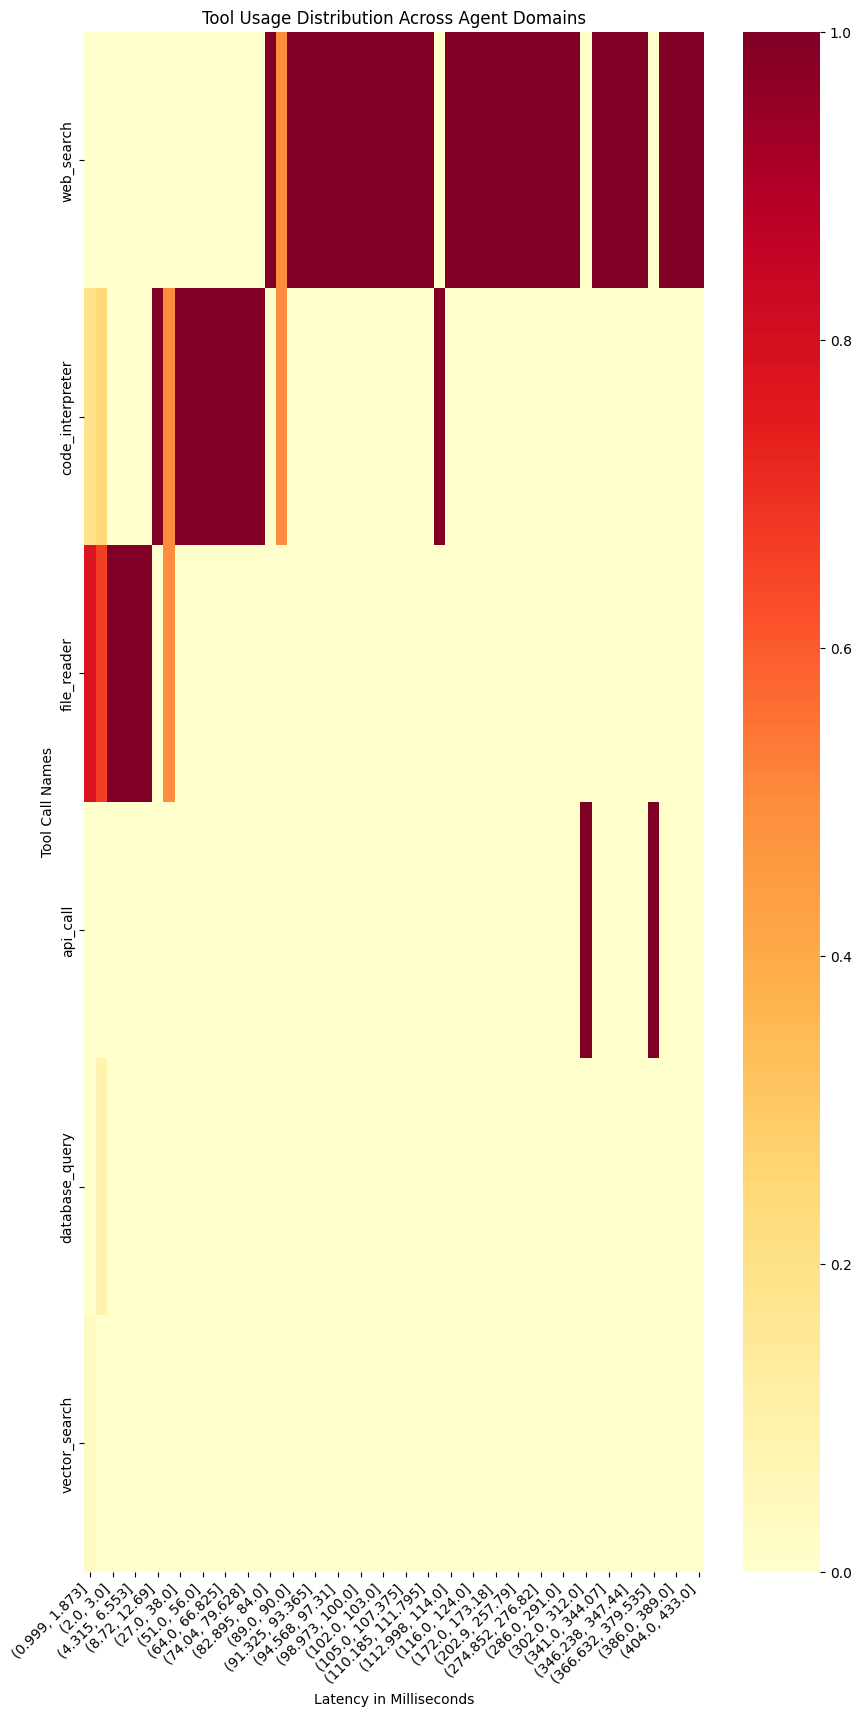

In [8]:
def associate_tool_names(df):
    """Generates a matrix to use within a heatmp visualization.
    
    Explodes tool_name and a target series and casting target to numeric.
    Target is then quantitatively cut into bins for a crosstab tranform for tabular data.
    Finally, the tools are sorted by target for a better visualization and reindexed.
    
    Args:
        df (pd.DataFrame): Cleaned agent latency DataFrame.
    
    Returns:
        ct (pd.crosstab): Transformed matrix for heatmap application.
    """
    target = "latency_ms"
    df = df[df["latency_ms"] > 0].sort_values(by=target)
    tools_exploded = df[["tool_name", target]].explode(target)
    tools_exploded = tools_exploded[tools_exploded[target].notna()]
    tools_exploded[target] = pd.to_numeric(tools_exploded[target])

    tools_exploded["execution_bins"] = pd.qcut(tools_exploded[target], q=400, duplicates="drop")

    ct = pd.crosstab(
        tools_exploded["tool_name"], 
        tools_exploded["execution_bins"], 
        normalize="columns"
    )

    ct = ct.sort_index(axis=1)

    tool_order = (
        tools_exploded.groupby("tool_name")[target]
        .mean()
        .sort_values()
        .index
    )
    
    return ct.reindex(index=tool_order)

tool_matrix = associate_tool_names(df)
tool_matrix = tool_matrix.loc[tool_matrix.sum(axis=1).sort_values(ascending=False).index]
plt.subplots(figsize=(10, 20))
cx = sns.heatmap(tool_matrix, annot=False, fmt=".5f", cmap="YlOrRd")
cx.set_title("Tool Usage Distribution Across Agent Domains")
cx.set_xlabel("Latency in Milliseconds")
cx.set_ylabel("Tool Call Names")
cx.set_xticklabels(cx.get_xticklabels(), rotation=45, ha="right")

## Hypothesis Test

### Null and Alternative Hypothesis

* H0: Memory pressure does not affect CPU-bound and IO-bound processes within an agentic environment.
* H1: Memory pressure does affect CPU-bound and IO-bound processes within an agentic environment.

In [9]:
from scipy.stats import pearson3

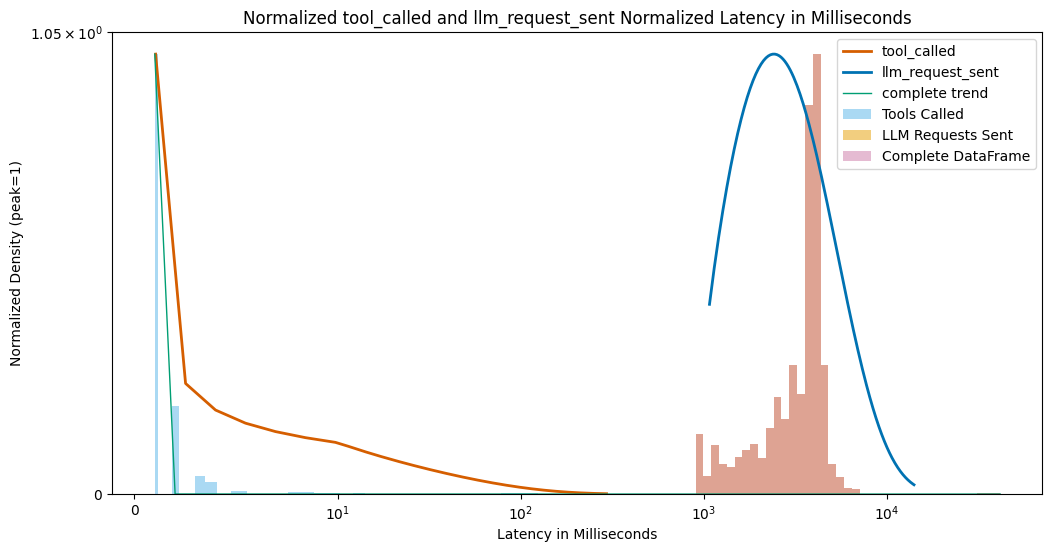

In [25]:
tool_color = '#D55E00'
llm_color = '#0072B2'
full_color = '#009E73'

tool_hist = '#56B4E9'
llm_hist = '#E69F00'
full_hist = '#CC79A7'

tool_called = "tool_called"
llm_request_sent = "llm_request_sent"

# We need to filter our latency over 0 since zero latency relates to local processes that don't require compute or networks.
tool_df = df[
    (df['event_type'].isin([tool_called])) & 
    (df['latency_ms'] > 0)
]['latency_ms'].dropna()

llm_df = df[
    (df['event_type'].isin([llm_request_sent])) &
    (df['latency_ms'] > 0)
]['latency_ms'].dropna()

full_df = df[
    (df['event_type'].isin([llm_request_sent, tool_called])) &
    (df['latency_ms'] > 0)
]['latency_ms'].dropna()
target_df = tool_df

# Fit data latency data to curve
skew, loc, scale = pearson3.fit(target_df)
lskew, lloc, lscale = pearson3.fit(llm_df)
fskew, floc, fscale = pearson3.fit(full_df)
# Generate partitioned data for smooth curve
x = np.linspace(
    # Using 1st and 99th percentile
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)
y = np.linspace(
    # Using 1st and 99th percentile
    pearson3.ppf(0.01, lskew, loc=lloc, scale=lscale),
    pearson3.ppf(0.99, lskew, loc=lloc, scale=lscale),
    200
)

def normalize_pdf(target, skew, loc, scale):
    pdf = pearson3.pdf(target, skew, loc=loc, scale=scale)
    return pdf / max(pdf)

def calculate_figure(target_df, scale=40, density=True):
    """Generates normalized counts and bin_edges for use in sns barcharts.
    
    Inserts the target_df.min() and target_df.max() into logspace by log10, with 40 slices.
    Calculates dependencies for histogram in np with density True and non-auto bin width.
    Normalizes counts for the return.
    
    Args:
        df (pd.DataFrame): Target DataFrame needing to be normalized for histogram.
    
    Returns:
        counts, bin_edges (int): Returns the normalized count of bars and the length of each bin width.
    """
    target_bins = np.logspace(np.log10(target_df.min()), np.log10(target_df.max()), scale)
    counts, bin_edges = np.histogram(target_df, bins=target_bins, density=density)
    maximum = counts.max()
    if maximum:
        counts = counts / counts.max()

    return counts, bin_edges

fig, ax = plt.subplots(figsize=(12, 6))

# ****TOOL_COUNTS****
tool_counts, tool_bin_edges = calculate_figure(tool_df)
ax.bar(tool_bin_edges[:-1], tool_counts, width=np.diff(tool_bin_edges), alpha=0.5, align='edge', label='Tools Called', color=tool_hist)

# ****LLM_COUNTS****
llm_counts, llm_bin_edges = calculate_figure(llm_df)
ax.bar(llm_bin_edges[:-1], llm_counts, width=np.diff(llm_bin_edges), alpha=0.5, align='edge', label='LLM Requests Sent', color=llm_hist)

# ****FULL_COUNTS****
full_counts, full_bin_edges = calculate_figure(llm_df)
ax.bar(full_bin_edges[:-1], full_counts, width=np.diff(full_bin_edges), alpha=0.5, align='edge', label='Complete DataFrame', color=full_hist)

random_variate = np.sort(full_df)
ax.plot(x, normalize_pdf(x, skew, loc, scale), tool_color, lw=2, label='tool_called')
ax.plot(y, normalize_pdf(y, lskew, lloc, lscale), llm_color, lw=2, label='llm_request_sent')
ax.plot(random_variate, normalize_pdf(random_variate, fskew, floc, fscale), full_color, lw=1, label='complete trend')

ax.set_xscale('symlog', linthresh=10)
ax.set_yscale('symlog', linthresh=10)
ax.set_title("Normalized tool_called and llm_request_sent Normalized Latency in Milliseconds")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Normalized Density (peak=1)")
ax.legend()

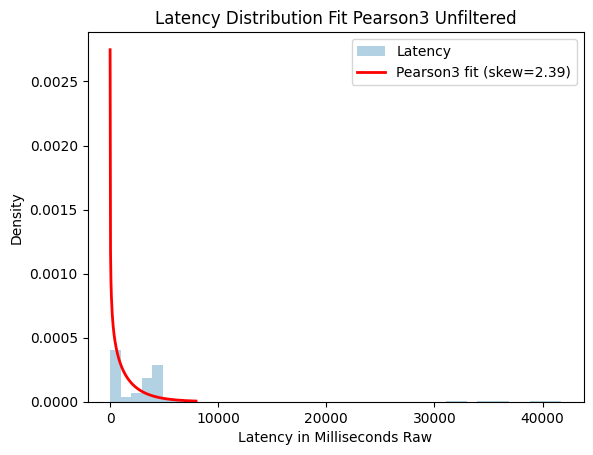

In [27]:
# white_list tool calls for hypothesis testing
whitelist_events = ["tool_called", "llm_request_sent"]
latency_data = df[
    (df['event_type'].isin(whitelist_events)) 
]['latency_ms'].dropna()

# fit the dataframe on pearson3
skew, loc, scale = pearson3.fit(latency_data)

# box the ppf into 200 boxes
x = np.linspace(
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)

fig, ax = plt.subplots()
ax.hist(latency_data, bins="auto", density=True, alpha=0.3, label="Latency")
ax.plot(
    x,
    pearson3.pdf(x, skew, loc=loc, scale=scale),
    'r-',
    lw=2,
    label=f'Pearson3 fit (skew={skew:.2f})'
)

ax.set_title("Latency Distribution Fit Pearson3 Unfiltered")
ax.set_xlabel("Latency in Milliseconds Raw")
ax.set_ylabel("Density")
ax.legend()

plt.show()


6     3358
14    4175
22    4627
30    2007
32    3656
Name: latency_ms, dtype: int64


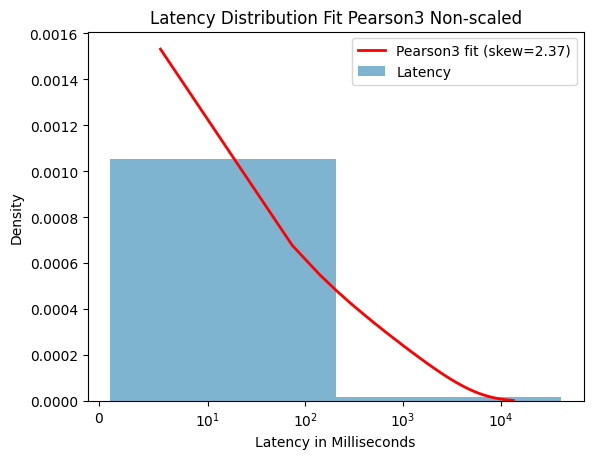

In [28]:
# white_list tool calls for hypothesis testing
whitelist_events = ["tool_called", "llm_request_sent"]
latency_data = df[
    (df['event_type'].isin(whitelist_events)) &
    (df['latency_ms'] > 0)
]['latency_ms'].dropna()
print(latency_data.head())
# fit the dataframe on pearson3
skew, loc, scale = pearson3.fit(latency_data)

# box the ppf into 200 boxes
x = np.linspace(
    pearson3.ppf(0.01, skew, loc=loc, scale=scale),
    pearson3.ppf(0.99, skew, loc=loc, scale=scale),
    200
)

fig, ax = plt.subplots()

# utilize logspace to enforce evenly separated bins, only 3 here for a simple visual
latency_bins = np.logspace(np.log10(latency_data.min()), np.log10(latency_data.max()), 3)
counts, bin_edges = np.histogram(latency_data, bins=latency_bins, density=True)
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), alpha=0.5, align='edge',label="Latency")
ax.plot(
    x,
    pearson3.pdf(x, skew, loc=loc, scale=scale),
    'r-',
    lw=2,
    label=f'Pearson3 fit (skew={skew:.2f})'
)
ax.set_xscale('symlog', linthresh=10)
ax.set_title("Latency Distribution Fit Pearson3 Non-scaled")
ax.set_xlabel("Latency in Milliseconds")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [ ]:
print("====Welch's Independent====")
# Welch's shows a simple metric of how our data skews
t_stat, p_val = stats.ttest_ind(tool_df, llm_df, equal_var=False)
print(f"Welch's independent t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

print("\n====Welch's Related====")
t_stat, p_val = stats.ttest_rel(tool_df, llm_df[:62])
print(f"Welch's related t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# Since my data is scaled I will used a spearmanr test to compare latency and memory pressure
tool_mem = lem_df[lem_df['event_type'] == 'tool_called'][['memory_mb', 'latency_ms', 'execution_ns']].dropna()
llm_mem = lem_df[lem_df['event_type'] == 'llm_request_sent'][['memory_mb', 'latency_ms', 'execution_ns']].dropna()

tool_r, tool_p = stats.spearmanr(tool_mem['memory_mb'], tool_mem['latency_ms'])
llm_r, llm_p = stats.spearmanr(llm_mem['memory_mb'], llm_mem['latency_ms'])

print("\n====Memory vs. Latency====")
print(f"tool_called:       rho={tool_r:.4f}, p={tool_p:.4e}")
print(f"llm_request_sent:  rho={llm_r:.4f}, p={llm_p:.4e}")

tool_r, tool_p = stats.spearmanr(tool_mem['execution_ns'], tool_mem['latency_ms'])
llm_r, llm_p = stats.spearmanr(llm_mem['execution_ns'], llm_mem['latency_ms'])

print("\n====Execution vs. Latency====")
print(f"tool_called:       rho={tool_r:.4f}, p={tool_p:.4e}")
print(f"llm_request_sent:  rho={llm_r:.4f}, p={llm_p:.4e}")

tool_r, tool_p = stats.spearmanr(tool_mem['execution_ns'], tool_mem['memory_mb'])
llm_r, llm_p = stats.spearmanr(llm_mem['execution_ns'], llm_mem['memory_mb'])

print("\n====Execution vs. Memory====")
print(f"tool_called:       rho={tool_r:.4f}, p={tool_p:.4e}")
print(f"llm_request_sent:  rho={llm_r:.4f}, p={llm_p:.4e}")

### Summary
Exploring latency characteristics across event types in an agentic AI environment.
#### What you explored
In an agentic system, latency comes from compute (model inference, tool execution) and coordination overhead (message passing between agent steps, memory retrieval, serialization), so we focused on three main features: *memory_mb*, *latency_ms*, and *execution_ns*.  We will consider two categories that generate inefficiencies within computing, scaling vertically using more RAM or delaying execution timing.  Since our computational environments are closed systems, using RAM in one place will lead to increased pressures on other processes, so the contention between time & memory will be our main focus.  Therefore, we are going to investigate how execution durations will relate directly to tool calling and llm requests sent.  For the purposes of this experiment, we isolate tool execution into two measurable components: the outbound network call (IO-bound, captured by latency_ms) and the local computation surrounding it (CPU-bound, captured by execution_ns). We can treat LLM inference requests as pure network calls where the compute happens remotely. Our defined separation can attribute latency contributions to local compute versus remote coordination.

#### Interesting/unexpected findings
We found an interesting curve showing divergence when latency increases in *llm_requests_sent*, which indicates the complication is not in the agent's actions itself, but waiting in isolation until the LLM responds with the exact moves it should make.  Nobody should be surprised by this if they took five minutes to think about it; however, the surprise is with the divergence in *execution_ns*, when a process needs to wait for a response it actually becomes harder for the task to be finished.  If it were a linear relationship, the line would be straight, instead we see a superlinear curve.

When performing our tests we didn't find signifigant differences between memory pressure on execution or on latency.  Since our p-values were so low for memory, we can conclude it does not have a direct correlation on latency as our hypothesis stated.  However, we did find something interesting, when plotting "Execution in Nanoseconds by Latency in Milliseconds" we found a superlinear curve once latency increased, execution increased as well.  When viewing these two factors, *llm_request_sent* for *execution_ns* x *latency_ms*, we see the major factor in what slows down our processes from completing.  The network call is naturally blocking the context and process, since we have an open listener waiting for the response to their network call, we are essentially "forgetting to free" the memory.  Right now there may not be an industry solution to this problem, but we can conclude the process waiting for a round-trip call to an LLM is creating inefficiences in our agentic systems.

#### Challenges
Multiple figures required symlog or log for effective visualization because of the variadic nature of our dataset.  Execution times are recorded in nanoseconds and latency is recorded in milliseconds, which enforced the need for scaling their measurements.  Since the raw data was indistinguishable from a flat line, originally, our biggest use of symlog was on "Normalized tool_called and llm_request_sent Normalized Latency in Milliseconds", which allowed us to detect a heavy-tailed distribution trend across the full spectrum of *llm_requests_sent* and *tool_called* in terms of latency, while preserving the distribution of higher latencies (8000ms+).  In order for the pearson3 to be fit correctly we needed to put all of our bins in logspace, and calculate the bar charts based off the modified bin_edges.  We also used the space from the 1st to 99th percentile in our data, enforcing a full curve over each cluster of data.

While composing "Normalized tool_called and llm_request_sent Normalized Latency in Milliseconds", we cut off certain values from the sequences, which is shown within the code.  The isolated curves show each latency profile of each event type, while the complete trend line shows the combined sum with minimal filtering to preserve the full tail behavior.  We had a situation, which is similar to mode collapse in a GAN, where our lower latency_ms buckets were accruing too many values, disproportionate to it's higher latency counterparts.  Through minor experimentation we found 4 to be a "magic number", which is purely for visualization purposes.  The full_df random variate ppf line we calculated can be set to zero on it's filter; subsequently, the trend remains the same, with a heavy tail within the ultra low-latency territories.